# Settings

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
import torch
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_undirected
import torch.serialization
from torch_geometric.data.data import Data, DataEdgeAttr

from GCN import GCN

import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx


/home/snehpatel/research/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device



device(type='cuda')

# Encoder

It takes in the dataset with the trace featrures and produces a `µ`, `logvar`, and `z`

In [3]:
class GraphEncoderVAE(nn.Module):
    """
    Graph encoder for a VAE:
    - Takes a trace graph (x, edge_index, batch)
    - Outputs latent parameters (mu, logvar) and a sampled latent vector z
    """
    def __init__ (self, n_pods, n_ops, duration_mean, duration_std, hidden_ch=128, embed_dim=48, latent_dim=64, dropout=0.35):
        super().__init__()
        
        self.pod_embeddings = nn.Embedding(n_pods, embed_dim)
        self.op_embeddings = nn.Embedding(n_ops, embed_dim)
        self.duration_encoder = nn.Sequential(
            nn.Linear(1, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        
        in_channels = embed_dim * 3
        self.conv1 = GCNConv(in_channels, hidden_ch)
        self.bn1 = nn.BatchNorm1d(hidden_ch)
        self.conv2 = GCNConv(hidden_ch,hidden_ch)
        self.bn2 = nn.BatchNorm1d(hidden_ch)
        
         # Graph-level representation size (same as before)
        self.lin_feat = nn.Linear(hidden_ch, hidden_ch// 2)
        self.dropout = dropout

        # --- VAE latent heads ---
        self.latent_dim = latent_dim
        self.mu_lin = nn.Linear(hidden_ch // 2, latent_dim)
        self.logvar_lin = nn.Linear(hidden_ch // 2, latent_dim)

        # duration normalization as buffers
        duration_std = max(duration_std, 1e-6)
        self.register_buffer("duration_mean", torch.tensor(duration_mean))
        self.register_buffer("duration_std", torch.tensor(duration_std))
    
    def build_feats(self, x):
        """
        Same feature construction as your GCN:
        - x[:,0] = pod id (categorical)
        - x[:,1] = op id  (categorical)
        - x[:,2] = duration (continuous)
        """
        pod_ids = x[:, 0].long().clamp(min=0, max=self.pod_embeddings.num_embeddings - 1)
        op_ids = x[:, 1].long().clamp(min=0, max=self.op_embeddings.num_embeddings - 1)

        duration = torch.clamp(x[:,2], min=0)
        duration = torch.log1p(duration)
        duration = (duration - self.duration_mean) / (self.duration_std + 1e-9)
        duration = duration.unsqueeze(-1)

        pod_feat = self.pod_embeddings(pod_ids)
        op_feat = self.op_embeddings(op_ids)
        duration_feat = self.duration_encoder(duration)

        return torch.cat([pod_feat, op_feat, duration_feat], dim=1)
    
    def encode_graph(self, x, edge_idx, batch):
        """
        Core GNN encoder: returns a graph-level feature vector h_graph.
        """
        feats = self.build_feats(x)
        
        h = self.conv1(feats, edge_idx)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv2(h,edge_idx)
        h = self.bn2(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # global graph representation
        h_graph = global_mean_pool(h, batch)  # [num_graphs, hidden_channels]
        h_graph = F.relu(self.lin_feat(h_graph))  # [num_graphs, hidden_channels//2]
        h_graph = F.dropout(h_graph, p=self.dropout, training=self.training)
        return h_graph
    
    def forward(self, x, edge_idx, batch):
        """
        Forward pass:
        returns (mu, logvar, z) for each graph in the batch.
        """
        h_graph = self.encode_graph(x, edge_idx, batch)
        
        mu = self.mu_lin(h_graph)
        logvar = self.logvar_lin(h_graph)

        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std
        else:
            z = mu
        
        return mu, logvar, z

    
    def encode(self, x, edge_idx, batch):
        """
        Convenience method: same as forward, but more explicit name.
        """ 
        
        return self.forward(x, edge_idx, batch)
        


# Load Data 

In [3]:
class LoadDataset(InMemoryDataset):
    def __init__(self, datapath="./data.pt") -> None:
        torch.serialization.add_safe_globals([Data, DataEdgeAttr])
        super().__init__(".")
        data, slices = torch.load(datapath, weights_only=False)
        self.data, self.slices = data, slices
        x = data.x
        self.num_pods = int(x[:, 0].max().item()) + 1
        self.num_ops = int(x[:, 1].max().item()) + 1
        log_duration = torch.log1p(torch.clamp(x[:, 2], min=0))
        self.duration_mean = log_duration.mean().item()
        self.duration_std = log_duration.std().item() or 1.0

    def get(self, idx):
        data = super().get(idx)
        data.edge_index = to_undirected(data.edge_index)
        return data

In [4]:
def summarize_dataset(dataset):

    # num_graphs = data["y"].size(0)
    print("=== DATASET SUMMARY ===")
    print(f"Total graphs: {len(dataset)}")

    labels = []
    total_nodes = 0

    for data in dataset:
        if hasattr(data, "y") and data.y is not None:
            if data.y.numel() == 1:
                labels.append(int(data.y.item()))
            else:
                labels.extend(data.y.tolist())

        total_nodes += data.num_nodes

    if len(labels) == 0:
        print("No Labels found in dataset")
        return

    y = torch.tensor(labels)
    unique_labels, counts = torch.unique(y, return_counts=True)

    print("\nLabel distribution:")
    for label, count in zip(unique_labels.tolist(), counts.tolist()):
        pct = 100.0 * count / len(y)
        print(f"  Label {label}: {count} graphs ({pct:.1f}%)")

    print(f"\nNumber of unique labels: {len(unique_labels)}")
    print(f"Total nodes across all graphs: {total_nodes}")
    print(f"Average nodes per graph: {total_nodes / len(dataset):.2f}")


def split_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Safely split a dataset into train and validation sets.
    Returns (train_dataset, val_dataset)
    """
    n_total = len(dataset)
    if n_total < 2:
        raise ValueError("Dataset must contain at least two graphs to split.")

    train_len = int(n_total * train_ratio)
    val_len = n_total - train_len  # ensures total matches exactly

    # Fix edge cases
    if train_len == 0:
        train_len = 1
        val_len = n_total - 1
    elif val_len == 0:
        val_len = 1
        train_len = n_total - 1

    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(
        dataset, [train_len, val_len], generator=generator
    )

    return train_dataset, val_dataset


def create_dataloaders(train_dataset, val_dataset, batch_size=32, num_workers=0):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    print(f"Dataloaders ready - batch size: {batch_size}")
    return train_loader, val_loader



In [7]:
def main():
    datapath = "./data.pt"
    dataset = LoadDataset(datapath)
    summarize_dataset(dataset)
    print(f"Unique Pods: {dataset.num_pods}, Unique Operations: {dataset.num_ops}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # encoder = GraphEncoderVAE(n_pods=dataset.num_pods, n_ops=dataset.num_ops, duration_mean=dataset.duration_mean, duration_std=dataset.duration_std, hidden_ch=128, embed_dim=48, latent_dim=64).to(device)
    
    loader = DataLoader(dataset, batch_size=8, shuffle=True)
    batch = next(iter(loader)).to(device)

    # mu, logvar, z = encoder(batch.x, batch.edge_index, batch.batch)
    
    # print(f"Mu Shape: {mu}]"
    #       f"\nLogVar Shape: {logvar.shape}"
    #       f"\nZ-shape: {z.shape}")
    
    # return mu, logvar, z

main()


=== DATASET SUMMARY ===
Total graphs: 2097

Label distribution:
  Label 0: 1089 graphs (51.9%)
  Label 1: 1008 graphs (48.1%)

Number of unique labels: 2
Total nodes across all graphs: 106020
Average nodes per graph: 50.56
Unique Pods: 28, Unique Operations: 200


In [7]:
z.device

device(type='cuda', index=0)

# Decoder 

Takes the parameters from the encoder and produces a synthetic graph using `VRDAG`

In [8]:

class GraphDecoderVRDAG(nn.Module):

    def __init__(self, latent_dim, n_pods, n_ops,
                 max_nodes=64, node_hidden_dim=128):
        super().__init__()

        self.latent_dim = latent_dim
        self.n_pods = n_pods
        self.n_ops = n_ops
        self.max_nodes = max_nodes
        self.node_hidden_dim = node_hidden_dim

        # Predict node count
        self.node_count_mlp = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, max_nodes)
        )

        # Positional embeddings
        self.pos_embeddings = nn.Embedding(max_nodes, node_hidden_dim)

        # Node hidden-state generator
        self.node_mlp = nn.Sequential(
            nn.Linear(latent_dim + node_hidden_dim, node_hidden_dim),
            nn.ReLU(),
            nn.Linear(node_hidden_dim, node_hidden_dim),
            nn.ReLU()
        )

        # Heads for node prediction
        self.pod_head = nn.Linear(node_hidden_dim, n_pods)
        self.op_head = nn.Linear(node_hidden_dim, n_ops)

        # 🔴 IMPORTANT: single scalar per node for duration (no 2-dim vector)
        self.duration_head = nn.Linear(node_hidden_dim, 1)

        # Edge scorer: score(j -> i)
        self.edge_score = nn.Bilinear(node_hidden_dim, node_hidden_dim, 1)

    # -------------------------------------------------------
    def sample_n_nodes(self, z, deterministic=False):
        """Predict number of nodes from latent z."""
        if z.dim() == 1:
            z = z.unsqueeze(0)

        logits = self.node_count_mlp(z)         # [1, max_nodes]
        probs = F.softmax(logits, dim=-1)

        if deterministic:
            idx = torch.argmax(probs, dim=-1).item()
        else:
            idx = torch.distributions.Categorical(probs).sample().item()

        n_nodes = idx + 1
        return max(1, min(self.max_nodes, n_nodes))

    # -------------------------------------------------------
    def decode_for_training(self, z, n_nodes=None):
        """
        Training mode:
            Returns:
              pod_logits:     [N, n_pods]
              op_logits:      [N, n_ops]
              duration_pred:  [N]
              edge_probs:     [N, N]
        """
        if z.dim() == 2 and z.size(0) == 1:
            z = z.squeeze(0)
        device = z.device

        # During training we FORCE n_nodes to match the real graph
        if n_nodes is None:
            n_nodes = self.sample_n_nodes(z, deterministic=True)
        n_nodes = max(1, min(self.max_nodes, int(n_nodes)))

        # Positions 0..N-1
        positions = torch.arange(n_nodes, device=device)
        pos_emb = self.pos_embeddings(positions)  # [N, H]

        # Broadcast z to each node
        z_broadcast = z.unsqueeze(0).expand(n_nodes, -1)  # [N, latent_dim]
        node_input = torch.cat([z_broadcast, pos_emb], dim=-1)  # [N, latent_dim+H]

        node_hidden = self.node_mlp(node_input)  # [N, H]

        # Node feature logits / predictions
        pod_logits = self.pod_head(node_hidden)      # [N, n_pods]
        op_logits  = self.op_head(node_hidden)       # [N, n_ops]

        # duration_pred: [N]
        duration_pred = self.duration_head(node_hidden).squeeze(-1).relu()

        # Edge probabilities matrix [N, N]
        edge_probs = torch.zeros((n_nodes, n_nodes), device=device)

        for i in range(1, n_nodes):
            h_i = node_hidden[i].unsqueeze(0)   # [1, H]
            h_prev = node_hidden[:i]            # [i, H]

            h_i_exp = h_i.expand(i, -1)         # [i, H]

            scores = self.edge_score(h_i_exp, h_prev).squeeze(-1)  # [i]
            probs = torch.sigmoid(scores)                           # [i]

            # column i, rows 0..i-1
            edge_probs[:i, i] = probs

        return pod_logits, op_logits, duration_pred, edge_probs

    # -------------------------------------------------------
    def decode_single(self, z, n_nodes=None, deterministic=False):
        """
        Sampling mode AFTER training:
        Returns a PyG Data object with:
          x: [N, 3] (pod_id, op_id, duration)
          edge_index: [2, E]
        """

        if z.dim() == 2 and z.size(0) == 1:
            z = z.squeeze(0)
        assert z.dim() == 1

        device = z.device

        if n_nodes is None:
            n_nodes = self.sample_n_nodes(z, deterministic)
        n_nodes = max(1, min(self.max_nodes, int(n_nodes)))

        positions = torch.arange(n_nodes, device=device)
        pos_emb = self.pos_embeddings(positions)

        z_broadcast = z.unsqueeze(0).expand(n_nodes, -1)
        node_input = torch.cat([z_broadcast, pos_emb], dim=-1)

        node_hidden = self.node_mlp(node_input)

        # pod
        pod_logits = self.pod_head(node_hidden)
        pod_probs = F.softmax(pod_logits, dim=-1)
        pod_ids = (
            torch.argmax(pod_probs, dim=-1)
            if deterministic
            else torch.distributions.Categorical(pod_probs).sample()
        )

        # op
        op_logits = self.op_head(node_hidden)
        op_probs = F.softmax(op_logits, dim=-1)
        op_ids = (
            torch.argmax(op_probs, dim=-1)
            if deterministic
            else torch.distributions.Categorical(op_probs).sample()
        )

        # duration: sample around predicted log-duration
        duration_log = self.duration_head(node_hidden).squeeze(-1)  # [N]
        if deterministic:
            log_dur = duration_log
        else:
            noise = 0.1 * torch.randn_like(duration_log)
            log_dur = duration_log + noise

        duration = torch.expm1(log_dur).clamp(min=0.0)  # [N]

        # Edges
        edge_index_list = []

        for i in range(1, n_nodes):
            h_i = node_hidden[i].unsqueeze(0)
            h_prev = node_hidden[:i]

            h_i_exp = h_i.expand(i, -1)
            scores = self.edge_score(h_i_exp, h_prev).squeeze(-1)
            edge_probs = torch.sigmoid(scores)

            if deterministic:
                edge_mask = edge_probs > 0.5
            else:
                edge_mask = torch.bernoulli(edge_probs).bool()

            candidates = torch.arange(i, device=device)
            js = candidates[edge_mask]

            if js.numel() > 0:
                src = js
                dst = torch.full((js.numel(),), i, dtype=torch.long, device=device)
                edge_index_list.append(torch.stack([src, dst], dim=0))

        if len(edge_index_list) > 0:
            edge_index = torch.cat(edge_index_list, dim=1)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long, device=device)

        x = torch.stack(
            [
                pod_ids.float(),
            op_ids.float(),
            duration.float(),
            ],
            dim=-1,
        )

        return Data(x=x, edge_index=edge_index)

In [9]:
from torch_geometric.loader import DataLoader

def test_generation():
    datapath = "./data.pt"
    dataset = LoadDataset(datapath)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1) Create encoder + decoder
    latent_dim = 64
    encoder = GraphEncoderVAE(
        n_pods=dataset.num_pods,
        n_ops=dataset.num_ops,
        duration_mean=dataset.duration_mean,
        duration_std=dataset.duration_std,
        hidden_ch=128,
        embed_dim=48,
        latent_dim=latent_dim,
    ).to(device)

    decoder = GraphDecoderVRDAG(
        latent_dim=latent_dim,
        n_pods=dataset.num_pods,
        n_ops=dataset.num_ops,
        max_nodes=64,
        node_hidden_dim=128,
    ).to(device)

    # 2) Take a real graph, encode it
    loader = DataLoader(dataset, batch_size=1, shuffle=True)
    real_batch = next(iter(loader)).to(device)

    mu, logvar, z = encoder(real_batch.x, real_batch.edge_index, real_batch.batch)
    # z: [1, latent_dim] -> use first
    z_single = z[0]  # [latent_dim]

    # 3) Decode a synthetic graph
    synthetic_graph = decoder.decode_single(z_single, deterministic=False)

    print("Synthetic graph:")
    print("  num_nodes:", synthetic_graph.num_nodes)
    print("  num_edges:", synthetic_graph.num_edges)
    print("  x shape:", synthetic_graph.x.shape)
    print("  edge_index shape:", synthetic_graph.edge_index.shape)

    return synthetic_graph


In [10]:
synthetic_graph = test_generation()

Synthetic graph:
  num_nodes: 34
  num_edges: 267
  x shape: torch.Size([34, 3])
  edge_index shape: torch.Size([2, 267])


# Visualize Synethic Graph

Displays the synthetic graph with nodes and edges

In [11]:
def visualize_graph(data, k=3, title="Synthetic Trace Graph"):
    G = to_networkx(data, to_undirected=False)

    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except:
        pos = nx.spring_layout(G, k=1.5, iterations=200, seed=42)
#    nx.spring_layout(G, k=1.5, iterations=200, seed=42) 
    plt.figure(figsize=(8,6))

    nx.draw_networkx_nodes(G, pos, node_size=450, node_color="lightblue")
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=18)

    labels = {i: f"{i}" for i in range(data.num_nodes)}
    nx.draw_networkx_labels(G, pos, labels, font_size=9)
    
    plt.title(title)
    plt.axis("off")
    plt.show()
    
    # Print the first k nodes features

    k = min(k, data.num_nodes)

    print(f"\n=== First {k} Nodes ===")

    for i in range(k):
        pod = int(data.x[i,0].item())
        op = int(data.x[i,1].item())
        duration = data.x[i,2].item()
        print(f"PodName: {pod}, Operation: {op}, Duration: {duration}")
    
    

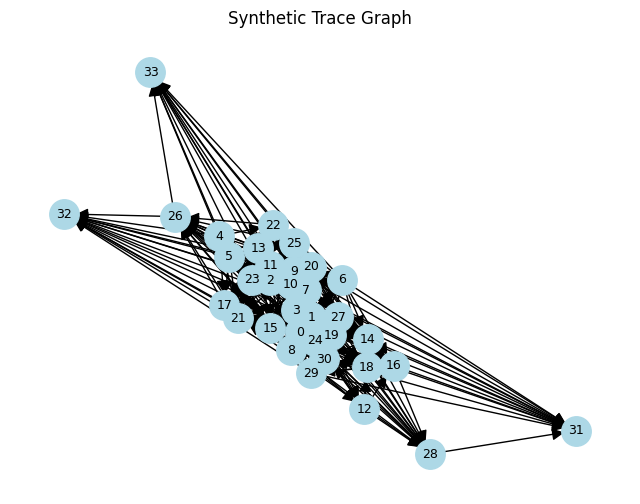


=== First 5 Nodes ===
PodName: 27, Operation: 127, Duration: 0.0
PodName: 20, Operation: 42, Duration: 0.0
PodName: 15, Operation: 67, Duration: 0.0
PodName: 15, Operation: 17, Duration: 0.08267590403556824
PodName: 21, Operation: 167, Duration: 0.0
Synthetic graph:
  num_nodes: 34
  num_edges: 267
  x shape: torch.Size([34, 3])
  edge_index shape: torch.Size([2, 267])


In [12]:
visualize_graph(synthetic_graph, k=5)

print("Synthetic graph:")
print("  num_nodes:", synthetic_graph.num_nodes)
print("  num_edges:", synthetic_graph.num_edges)
print("  x shape:", synthetic_graph.x.shape)
print("  edge_index shape:", synthetic_graph.edge_index.shape)

# Training 

Trains the encoder-decoder architecture over epochs for better results

In [13]:
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx

In [14]:
def identity_sort_graph(data: Data) -> Data:
    """
    Do NOT change node order.
    Just ensure .batch exists and is on the right device.
    """
    device = data.x.device
    new_data = Data(x=data.x, edge_index=data.edge_index)

    if hasattr(data, "y"):
        new_data.y = data.y

    new_data.batch = torch.zeros(new_data.num_nodes, dtype=torch.long, device=device)
    return new_data

In [15]:
def topo_sort_graph(data):
    """
    Sort graphs based on topologically order
    Convert PyG graph -> networkx
    Topologically sort it
    Reorder x and edge_index accordingly
    """
    device = data.x.device

    G = to_networkx(data, to_undirected=False)

    # Try standard topological sort
    try:
        order = list(nx.topological_sort(G))
    except nx.NetworkXUnfeasible:
        # Graph contains a cycle → fall back to a safe ordering

        # Use a deterministic fallback:
        # Order by in-degree, then node index
        order = sorted(G.nodes(), key=lambda n: (G.in_degree(n), n))

        # If STILL invalid, fallback to identity order
        if len(order) != data.num_nodes:
            order = list(range(data.num_nodes))

    # Reorder features
    x_new = data.x[order]

    # Reorder edges
    mapping = {old: new for new, old in enumerate(order)}
    new_edges = []
    for src, dst in data.edge_index.t().tolist():
        new_edges.append([mapping[src], mapping[dst]])

    if len(new_edges) > 0:
        edge_index_new = torch.tensor(new_edges, dtype=torch.long, device=device).t()
    else:
        edge_index_new = torch.empty((2, 0), dtype=torch.long, device=device)

    new_data = Data(x=x_new, edge_index=edge_index_new)

    # Preserve label
    if hasattr(data, "y"):
        new_data.y = data.y

    # Restore batch (safe for batch_size=1)
    new_data.batch = torch.zeros(x_new.size(0), dtype=torch.long, device=device)

    return new_data
    

In [16]:
def node_recon_loss(real_x, pod_logits, op_logits, duration_pred):
    """ 
    Reconstruction loss for nodes
    Node feat loss
    feats are [pod, op, duration]
    """
    N = real_x.size(0)
    assert pod_logits.size(0) == N, f"pod_logits N={pod_logits.size(0)} vs real N={N}"
    assert op_logits.size(0)  == N, f"op_logits N={op_logits.size(0)} vs real N={N}"
    assert duration_pred.size(0) == N, f"duration_pred N={duration_pred.size(0)} vs real N={N}"
    
    pod_real = real_x[:,0].long()
    op_real = real_x[:,1].long()
    duration_real = real_x[:,2]

    pod_loss = F.cross_entropy(pod_logits, pod_real)
    op_loss = F.cross_entropy(op_logits, op_real)
    duration_loss = F.l1_loss(duration_pred, duration_real)
    
    return pod_loss + op_loss + duration_loss

In [17]:
def edge_recon_loss(real_edges, pred_edge_probs, n_nodes, device):
    """ 
    Reconstruction loss for edges
    VRDAG style edges only allowed from j < i
    """
    assert pred_edge_probs.size(0) == n_nodes and pred_edge_probs.size(1) == n_nodes, \
        f"edge_probs must be [{n_nodes}, {n_nodes}], got {pred_edge_probs.shape}"

    adj_real = torch.zeros((n_nodes, n_nodes), device=device)
    if real_edges.numel() > 0:
        assert real_edges.dim() == 2 and real_edges.size(0) == 2, \
            f"real_edges should be [2, E], got {real_edges.shape}"
        adj_real[real_edges[0], real_edges[1]] = 1.0

    mask = torch.triu(torch.ones(n_nodes, n_nodes, device=device), diagonal=1).bool()

    real = adj_real[mask]             # [M]
    pred = pred_edge_probs[mask]      # [M]
    assert real.shape == pred.shape, \
        f"real edge vec shape {real.shape} vs pred {pred.shape}"

    if real.numel() == 0:
        # No possible edges -> return 0 edge loss
        return torch.tensor(0.0, device=device)

    return F.binary_cross_entropy(pred, real)

In [18]:
def kl_loss(mu, logvar, clamp_min=-8.0, clamp_max=8.0): 
    """ 
    Calculate KL loss
    Clamp_min/max is a hyper param  
    """
    logvar = torch.clamp(logvar, min=clamp_min, max=clamp_max)

    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1)
    return kl_per_sample.mean()

In [19]:
def total_vae_loss(real_data, pod_logits, op_logits, duration_pred, pred_edge_probs, mu, logvar, beta=0.1):
    """Combine node and edge loss"""
    real_x = real_data.x
    real_edges = real_data.edge_index
    n_nodes = real_data.num_nodes
    device = real_x.device
    
    node_l = node_recon_loss(real_x, pod_logits, op_logits, duration_pred)
    edge_l = edge_recon_loss(real_edges, pred_edge_probs, n_nodes, device)
    kl_l = kl_loss(mu, logvar)

    # Calculate the loss
    calc = node_l + edge_l + beta * kl_l
    return calc, node_l, edge_l, kl_l

In [20]:
def train_vae_epoch(encoder, decoder, loader, optimizer, device, beta=0.1):
    encoder.train()
    decoder.train()
    
    total_loss_val = 0.0
    total_node = 0.0
    total_edge = 0.0
    total_kl = 0.0

    for data in loader:
        data = data.to(device)

        # sort topologically
        data = identity_sort_graph(data)
        optimizer.zero_grad()

        #encode
        mu, logvar, z = encoder(data.x, data.edge_index, data.batch)
        n_nodes = data.num_nodes
        pod_logits, op_logits, duration_pred, edge_probs = decoder.decode_for_training(z[0], n_nodes=n_nodes)

        # Sanity check
        assert pod_logits.size(0) == n_nodes, "Decoder pod_logits N mismatch"
        assert edge_probs.size(0) == n_nodes, "Decoder edge_probs N mismatch"

        loss_val, node_l, edge_l, kl_l = total_vae_loss(data, pod_logits, op_logits, duration_pred, edge_probs, mu, logvar, beta)

        # Backpropagation
        loss_val.backward()
        optimizer.step()

        # Accumulate
        total_loss_val += loss_val.item()
        total_node += node_l.item()
        total_edge += edge_l.item()
        total_kl += kl_l.item()

    return total_loss_val / len(loader), total_node / len(loader), total_edge / len(loader), total_kl / len(loader)


In [21]:
def run_training(dataset, encoder, decoder, device, epochs=20, batch_size=1, lr=1e-5, beta=0.1):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=lr
    )

    for epoch in range(1, epochs+1):
        max_beta = 0.1
        # For 200 epochs first 50 will be warmup
        warmup_epochs = epochs * 0.25 
        beta = max_beta * min(1.0, epoch / warmup_epochs)
        loss, recon, edge_loss, kl = train_vae_epoch(
            encoder, decoder, loader, optimizer, device, beta
        )
        
        print(f"Epoch {epoch}"
            f"\n  Loss:     {loss:.4f}", 
            f"\n  Recon:    {recon:.4f}"
            f"\n  Edge:     {edge_loss:.4f}"
            f"\n  KL:       {kl:.4f}")
        

In [22]:
datapath = "./data.pt"
dataset = LoadDataset(datapath)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Create encoder + decoder
latent_dim = 64
encoder = GraphEncoderVAE(
    n_pods=dataset.num_pods,
    n_ops=dataset.num_ops,
    duration_mean=dataset.duration_mean,
    duration_std=dataset.duration_std,
    hidden_ch=128,
    embed_dim=48,
    latent_dim=latent_dim,
).to(device)


loader = DataLoader(dataset, batch_size=8, shuffle=True)

max_nodes = max(g.num_nodes for g in dataset)
print("Max nodes in dataset:", max_nodes)
# batch = next(iter(loader)).to(device)
# mu, logvar, z = encoder(batch.x, batch.edge_index, batch.batch)

# print("mu:", mu.shape)
# print("logvar:", logvar.shape)
# print("z:", z.shape)

decoder = GraphDecoderVRDAG(
    latent_dim=latent_dim,
    n_pods=dataset.num_pods,
    n_ops=dataset.num_ops,
    max_nodes=256,      # or 200, but 256 gives a bit of headroom
    node_hidden_dim=128,
).to(device)

run_training(dataset, encoder, decoder, device, epochs=200, batch_size=1, lr=1e-4, beta=0.1)
# def run_training(dataset, encoder, decoder, device, epochs=20, batch_size=1, lr=1e-5, beta=0.1):

Max nodes in dataset: 200
Epoch 1
  Loss:     18037.8458 
  Recon:    18027.4800
  Edge:     5.8483
  KL:       2258.7119
Epoch 2
  Loss:     17263.1766 
  Recon:    17253.8507
  Edge:     6.4954
  KL:       707.6455
Epoch 3
  Loss:     17025.2524 
  Recon:    17015.8265
  Edge:     6.4964
  KL:       488.2703
Epoch 4
  Loss:     16945.7464 
  Recon:    16936.0718
  Edge:     6.5086
  KL:       395.7534
Epoch 5
  Loss:     16900.7729 
  Recon:    16891.0116
  Edge:     6.4878
  KL:       327.3660
Epoch 6
  Loss:     16866.5626 
  Recon:    16856.8785
  Edge:     6.4988
  KL:       265.4404
Epoch 7
  Loss:     16842.0418 
  Recon:    16832.5769
  Edge:     6.4706
  KL:       213.8750
Epoch 8
  Loss:     16812.8137 
  Recon:    16803.6818
  Edge:     6.4723
  KL:       166.2287
Epoch 9
  Loss:     16774.4065 
  Recon:    16765.8766
  Edge:     6.4672
  KL:       114.6024
Epoch 10
  Loss:     16707.3854 
  Recon:    16699.6534
  Edge:     6.4678
  KL:       63.2083
Epoch 11
  Loss:     16

In [23]:
def generate_synthetic_trace(decoder, latent_dim, device, 
                             n_nodes=None, deterministic=False):
    decoder.eval()

    with torch.no_grad():
        # Sample z ~ N(0, I)
        z = torch.randn(latent_dim, device=device)
        
        # Let decoder choose n_nodes if None, or force it
        data = decoder.decode_single(z, n_nodes=n_nodes, deterministic=deterministic)

    return data

Data(x=[61, 3], edge_index=[2, 0])
Nodes: 61
Edges: 0


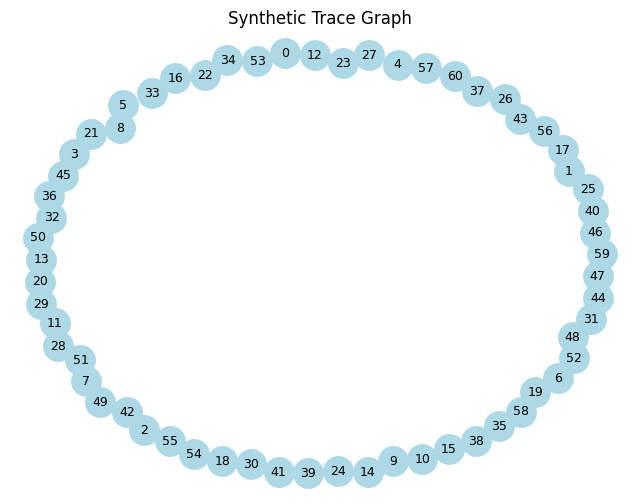


=== First 5 Nodes ===
PodName: 9, Operation: 0, Duration: inf
PodName: 2, Operation: 7, Duration: inf
PodName: 9, Operation: 7, Duration: inf
PodName: 2, Operation: 7, Duration: inf
PodName: 2, Operation: 7, Duration: inf


In [25]:
latent_dim = 64  # same as you used for training

synthetic_graph = generate_synthetic_trace(
    decoder, latent_dim, device, 
    n_nodes=None,          # or e.g. 50 to force 50 nodes
    deterministic=False    # True = no sampling randomness
)

print(synthetic_graph)
print("Nodes:", synthetic_graph.num_nodes)
print("Edges:", synthetic_graph.edge_index.size(1))
visualize_graph(synthetic_graph, k=5)

# Evaluation

Eval the synthetic graphs

In [26]:
@torch.no_grad()
def evaluate_reconstruction(dataset, encoder, decoder, device,
                            batch_size=1, edge_threshold=0.5):
    """
    Quantitatively evaluate how well the VAE reconstructs graphs.

    Metrics:
      - pod_acc:   accuracy over pod IDs
      - op_acc:    accuracy over op IDs
      - dur_mae:   mean absolute error on duration
      - edge_precision / recall / F1: on upper-triangular edges (j < i)
    """

    encoder.eval()
    decoder.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    total_nodes = 0
    correct_pod = 0
    correct_op = 0
    duration_abs_err = 0.0

    # Edge metrics
    edge_TP = 0
    edge_FP = 0
    edge_FN = 0

    for data in loader:
        data = data.to(device)
        # keep node order but add batch
        data = identity_sort_graph(data)

        # Encode
        mu, logvar, z = encoder(data.x, data.edge_index, data.batch)

        # For batch_size=1, take z[0]
        z0 = z[0]
        n_nodes = data.num_nodes

        # Decode in "training-style" to get logits + probs
        pod_logits, op_logits, duration_pred, edge_probs = decoder.decode_for_training(
            z0, n_nodes=n_nodes
        )

        # ----- Node metrics -----
        real_x = data.x
        pod_real = real_x[:, 0].long()
        op_real  = real_x[:, 1].long()
        dur_real = real_x[:, 2]

        pod_pred = pod_logits.argmax(dim=1)
        op_pred  = op_logits.argmax(dim=1)
        dur_pred = duration_pred  # already [N]

        total_nodes += n_nodes
        correct_pod += (pod_pred == pod_real).sum().item()
        correct_op  += (op_pred == op_real).sum().item()
        duration_abs_err += torch.abs(dur_pred - dur_real).sum().item()

        # ----- Edge metrics -----
        # Build real adjacency
        real_edges = data.edge_index
        adj_real = torch.zeros((n_nodes, n_nodes), device=device)
        if real_edges.numel() > 0:
            adj_real[real_edges[0], real_edges[1]] = 1.0

        # Predicted adjacency
        adj_pred = (edge_probs > edge_threshold).float()

        # As in training, only consider j < i (upper-triangular)
        mask = torch.triu(torch.ones(n_nodes, n_nodes, device=device), diagonal=1).bool()
        real_vec = adj_real[mask]
        pred_vec = adj_pred[mask]

        TP = ((pred_vec == 1) & (real_vec == 1)).sum().item()
        FP = ((pred_vec == 1) & (real_vec == 0)).sum().item()
        FN = ((pred_vec == 0) & (real_vec == 1)).sum().item()

        edge_TP += TP
        edge_FP += FP
        edge_FN += FN

    # ----- Aggregate metrics -----
    pod_acc = correct_pod / total_nodes if total_nodes > 0 else 0.0
    op_acc  = correct_op  / total_nodes if total_nodes > 0 else 0.0
    dur_mae = duration_abs_err / total_nodes if total_nodes > 0 else 0.0

    precision = edge_TP / (edge_TP + edge_FP) if (edge_TP + edge_FP) > 0 else 0.0
    recall    = edge_TP / (edge_TP + edge_FN) if (edge_TP + edge_FN) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    print("\n=== Reconstruction Evaluation ===")
    print(f"Total nodes evaluated: {total_nodes}")
    print(f"Pod accuracy: {pod_acc*100:.2f}%")
    print(f"Op accuracy:  {op_acc*100:.2f}%")
    print(f"Duration MAE: {dur_mae:.4f}")
    print(f"Edge precision: {precision*100:.2f}%")
    print(f"Edge recall:    {recall*100:.2f}%")
    print(f"Edge F1:        {f1*100:.2f}%")

    return {
        "pod_acc": pod_acc,
        "op_acc": op_acc,
        "dur_mae": dur_mae,
        "edge_precision": precision,
        "edge_recall": recall,
        "edge_f1": f1,
    }


In [27]:
metrics = evaluate_reconstruction(dataset, encoder, decoder, device)


=== Reconstruction Evaluation ===
Total nodes evaluated: 106020
Pod accuracy: 53.94%
Op accuracy:  45.97%
Duration MAE: 55652.6669
Edge precision: 36.88%
Edge recall:    3.06%
Edge F1:        5.66%


In [65]:
metrics

{'pod_acc': 0.5688643652141105,
 'op_acc': 0.4651197887191096,
 'dur_mae': 24195.576345928246,
 'edge_precision': 0.6973981900452488,
 'edge_recall': 0.011864553563696199,
 'edge_f1': 0.02333216640962807}